In [1]:
import numpy as np
import pandas as pd
import os
import logging
from datetime import datetime
from pyproj import Proj
from scipy.interpolate import interp1d
from scipy.interpolate import PchipInterpolator
import math
import matplotlib.pyplot as plt 
from pathlib import Path
from matplotlib.ticker import MultipleLocator


logger = logging.getLogger(__name__)

# -----------------------------------------------------------
# 전역(글로벌) Proj 객체: UTM zone 52N (EPSG:32652)
# 위경도 좌표를 UTM(동-북) 좌표로 변환하기 위해 사용
# -----------------------------------------------------------
_proj_utm52 = Proj("epsg:32652")


class DataProcessor:
    def __init__(self, window_size=200):
        self.window_size = window_size
        
    @staticmethod
    def load_and_preprocess_csv(file_path, skiprows=100, skipfooter=100, flag=False, zone=52, window_size=200):
        if flag:
            df = pd.read_csv(file_path, skiprows=skiprows, skipfooter=skipfooter,
                             na_values=['', 'nan', 'NaN'], engine='python').fillna(0)
        else:
            df = pd.read_csv(file_path, skiprows=skiprows, skipfooter=skipfooter, engine='python')
            
        df.columns = [
            'Time',
            'Accelerometer x', 'Accelerometer y', 'Accelerometer z',
            'Gyroscope x', 'Gyroscope y', 'Gyroscope z',
            'Magnetometer x', 'Magnetometer y', 'Magnetometer z',
            'Orientation x', 'Orientation y', 'Orientation z',
            'Pressure', 'Latitude', 'Longitude', 'Altitude', 'Speed_GPS'
        ]

        df['Time'] = pd.to_datetime(df['Time'], format='%Y-%m-%d %H:%M:%S.%f')
        start_dt = df['Time'].iloc[0]
        df['Elapsed Time'] = (df['Time'] - start_dt).dt.total_seconds()
        
        df['Acc_Norm'] = np.linalg.norm(df[['Accelerometer x', 'Accelerometer y', 'Accelerometer z']].values, axis=1)
        df['Gyro_Norm'] = np.linalg.norm(df[['Gyroscope x', 'Gyroscope y', 'Gyroscope z']].values, axis=1)
        
        e, n = DataProcessor.llh_to_enu(df, flag, zone)
        v_10hz, dh_10Hz = DataProcessor.interpol_vAndh(e, n)
        X, Y = DataProcessor.makeXY(df, v_10hz, dh_10Hz, window_size=window_size)
        
        
        y_e = []
        y_n = []
        dx = 0.0
        dy = 0.0 
        heading = 0
        
        stride = 1
        
        for v, h in zip(Y[:, 0], Y[:, 1]):
            heading += h * (stride/200)
            dx += (v * (stride/200)) * np.cos(heading)
            dy += (v * (stride/200)) * np.sin(heading)
            y_e.append(dx)
            y_n.append(dy)
            
        plt.plot(y_e, y_n, '.-')
        plt.grid()
        plt.axis('equal')
        plt.show()
        
        plt.plot(np.degrees(np.cumsum(Y[:, 1])*(stride/200)))
        plt.gca().yaxis.set_major_locator(MultipleLocator(90))
        plt.grid()
        plt.show()
        return df, X, Y
    
    @staticmethod
    def llh_to_enu(df, flag, zone=52):
        if flag:
            valid_gps_mask = (
                df['Latitude'].notna() & df['Longitude'].notna() &
                (df['Latitude'].astype(str).str.strip() != '') &
                (df['Longitude'].astype(str).str.strip() != '')
            )
            valid_lat = pd.to_numeric(df.loc[valid_gps_mask, 'Latitude'], errors='coerce')
            valid_lon = pd.to_numeric(df.loc[valid_gps_mask, 'Longitude'], errors='coerce')
            final_mask = valid_lat.notna() & valid_lon.notna()
            valid_lat = valid_lat[final_mask].values
            valid_lon = valid_lon[final_mask].values
            if len(valid_lat) == 0:
                raise ValueError("유효한 GPS 데이터가 없습니다.")
            proj_enu = Proj(proj='utm', zone=zone, ellps='WGS84', south=False)
            e0, n0 = proj_enu(valid_lon[0], valid_lat[0])
            e_valid, n_valid = proj_enu(valid_lon, valid_lat)
            e_valid -= e0; n_valid -= n0
            df['E'], df['N'] = np.nan, np.nan
            df.loc[valid_gps_mask, 'E'] = e_valid
            df.loc[valid_gps_mask, 'N'] = n_valid
            e = df['E'][df['E'].notna()].values
            n = df['N'][df['N'].notna()].values
            return e, n
        else:
            df['Latitude']  = pd.to_numeric(df['Latitude'],  errors='coerce')
            df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')
            proj_enu = Proj(proj='utm', zone=zone, ellps='WGS84', south=False)
            e_all, n_all = proj_enu(df['Longitude'].values, df['Latitude'].values)
            e0, n0 = proj_enu(df['Longitude'].iloc[0], df['Latitude'].iloc[0])
            df['E'] = e_all - e0
            df['N'] = n_all - n0
            M = len(df)
            n_sec = M // 50
            e, n = [], []
            for i in range(n_sec):
                idx = min(i*50 + 25, M-1)
                e.append(df['E'].iloc[idx])
                n.append(df['N'].iloc[idx])
            e = np.array(e)
            n = np.array(n)
            return e, n
            
    @staticmethod
    def interpol_vAndh(e, n):
        delta_e = np.diff(e)
        delta_n = np.diff(n)
        


        v_1hz = np.hypot(delta_e, delta_n)

        theta = np.arctan2(delta_n, delta_e)                     # 1Hz 혹은 원 샘플 기준 각
        theta_u = np.unwrap(theta, discont=np.pi/2)              # ← 먼저 언랩(더 깐깐: π/2)
        dh = np.diff(theta_u)                                    # ← 그 다음 차분

        # 저속 구간 마스킹(권장)
        eps = 1e-2  # 단위에 맞게 조정(예: m/step)
        mask = (v_1hz[:-1] > eps) & (v_1hz[1:] > eps)
        dh_1hz = np.where(mask, dh, 0.0)                       # 0 또는 보간 처리
        
        # v_1hz = (delta_e**2 + delta_n**2)**0.5
        # dh_1hz = np.diff(np.unwrap(np.arctan2(delta_n, delta_e)))
        
        origin_v = v_1hz[1:]
        origin_dh = dh_1hz

        N = len(origin_v)                  # 1Hz 샘플 수
        t = np.arange(N, dtype=float)      # 0..N-1
        #t_new = np.linspace(0.0, N-1, (N-1)*10 + 1)  # ✅ 10Hz로 0~N-1초, 총 (N-1)*10+1개
        t_new = np.linspace(0.0, N-1, (N-1)*50 + 1)  # ✅ 10Hz로 0~N-1초, 총 (N-1)*10+1개
        pv  = PchipInterpolator(t, origin_v)
        pdh = PchipInterpolator(t, origin_dh)
        v_10Hz  = pv(t_new)
        dh_10Hz = pdh(t_new)
        
        return v_10Hz, dh_10Hz
    
    @staticmethod
    def makeXY(df, v_10Hz, dh_10Hz, window_size):
        stride = 1
        sensor_cols = ['Accelerometer x','Accelerometer y','Accelerometer z',
                'Gyroscope x','Gyroscope y','Gyroscope z',
                'Acc_Norm',
                'Gyro_Norm']

        X = []
        for i in range(0, len(df) - window_size + 1, stride):
            window = df[sensor_cols].iloc[i:i+window_size].values  # (200, 8) numpy array
            X.append(window)

        X = np.array(X)  # (n, 200, 8)

        Y_v = []
        Y_dh = []

        offsets = [0, 50, 100, 150]   # 1초 간격 (10Hz 기준)
        for i in range(len(dh_10Hz) - max(offsets)):
            # v: 1초 단위 4개를 합
            Y_v.append(v_10Hz[i + offsets[0]] +
                    v_10Hz[i + offsets[1]] +
                    v_10Hz[i + offsets[2]] +
                    v_10Hz[i + offsets[3]])

            Y_dh.append(dh_10Hz[i + offsets[0]] +
                    dh_10Hz[i + offsets[1]] +
                    dh_10Hz[i + offsets[2]] +
                    dh_10Hz[i + offsets[3]])  # 10Hz × 40 = 4초
        Y = np.stack([Y_v, Y_dh], axis=1)
        X = X[:len(Y)]
        return X, Y
    
    
    @staticmethod
    def load_and_preprocess_csv_test(file_path, skiprows=50):
        # ... 기존 테스트용 전처리 로직 그대로 유지 ...
        df = pd.read_csv(
        file_path, skiprows=skiprows, skipfooter=100, engine='python'
        )

        df.columns = [
            'Time',
            'Accelerometer x','Accelerometer y','Accelerometer z',
            'Gyroscope x','Gyroscope y','Gyroscope z',
            'Magnetometer x','Magnetometer y','Magnetometer z',
            'Orientation x','Orientation y','Orientation z',
            'Pressure','Latitude','Longitude','Altitude','Speed_GPS'
        ]
        df['Time'] = pd.to_datetime(df['Time'], format='%Y-%m-%d %H:%M:%S.%f')
        start_dt = df['Time'].iloc[0]
        df['Elapsed Time'] = (df['Time'] - start_dt).dt.total_seconds()

        df['Acc_Norm'] = np.linalg.norm(
            df[['Accelerometer x','Accelerometer y','Accelerometer z']].values, axis=1
        )
        df['Gyro_Norm'] = np.linalg.norm(
            df[['Gyroscope x','Gyroscope y','Gyroscope z']].values, axis=1
        )

        return df

=== SWING 데이터 ===


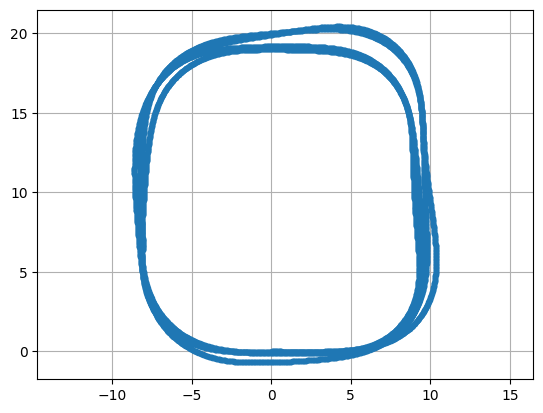

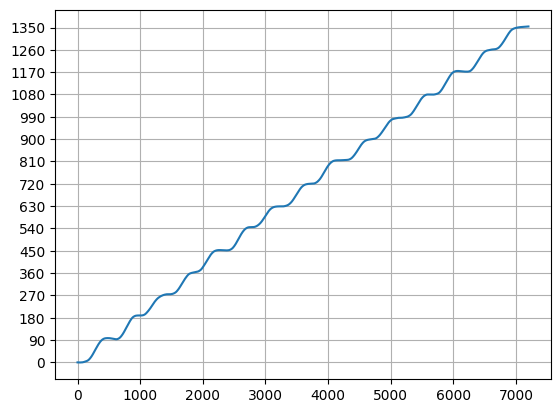

[01] swing_left01.csv                 길이:   7530  ≈   2.51 분  opts={'skiprows': 200, 'flag': False, 'zone': 52}


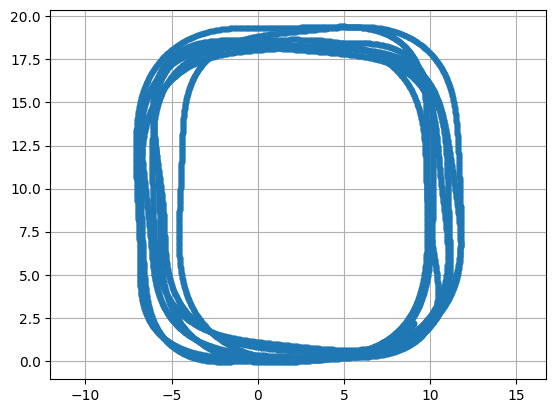

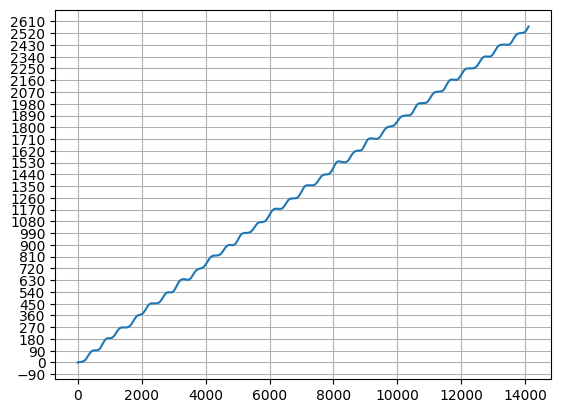

[02] swing_left02.csv                 길이:  14427  ≈   4.81 분  opts={'skiprows': 400, 'flag': False, 'zone': 52}


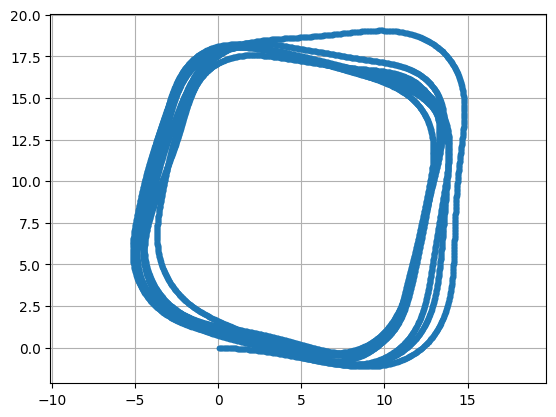

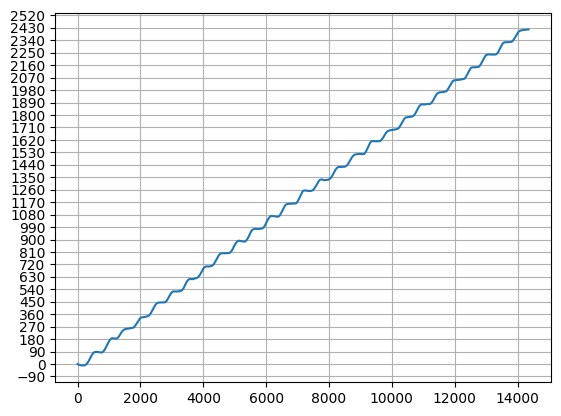

[03] swing_left03.csv                 길이:  14662  ≈   4.89 분  opts={'skiprows': 200, 'flag': False, 'zone': 52}


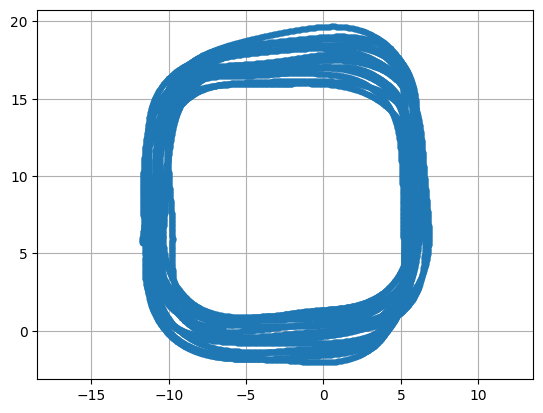

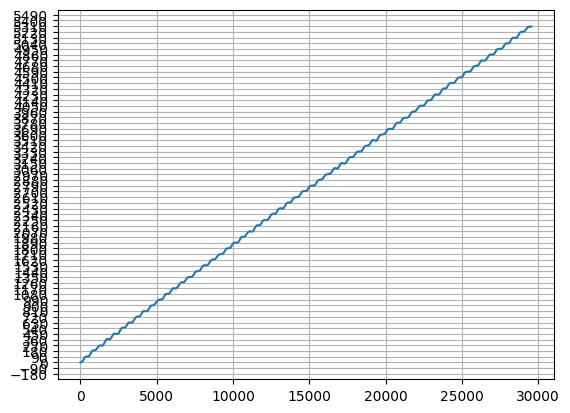

[04] swing_left04.csv                 길이:  29806  ≈   9.94 분  opts={'skiprows': 300, 'flag': True, 'zone': 52}


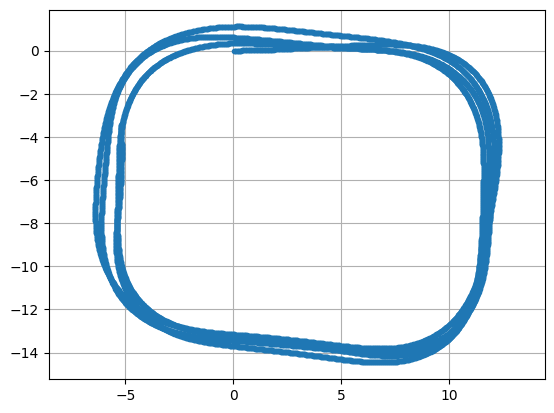

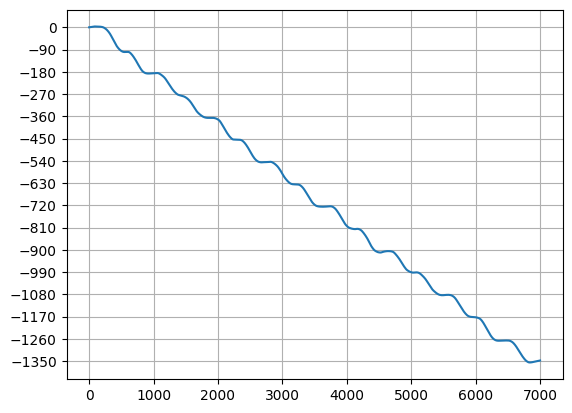

[05] swing_right01.csv                길이:   7344  ≈   2.45 분  opts={'skiprows': 150, 'flag': False, 'zone': 52}


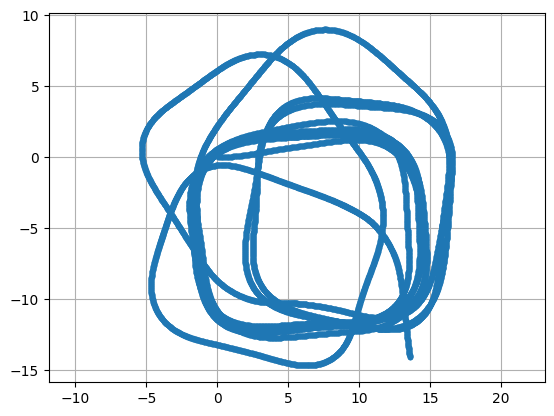

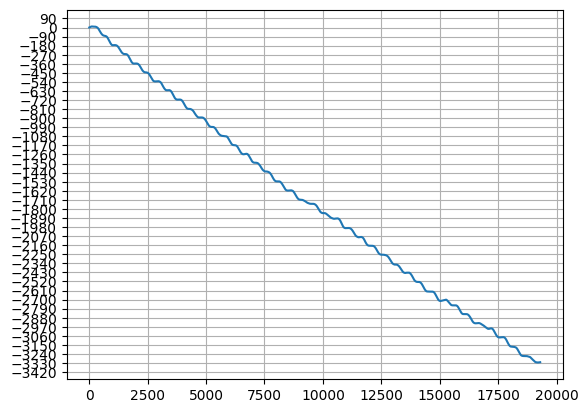

[06] swing_right02.csv                길이:  19602  ≈   6.53 분  opts={'skiprows': 300, 'flag': False, 'zone': 52}


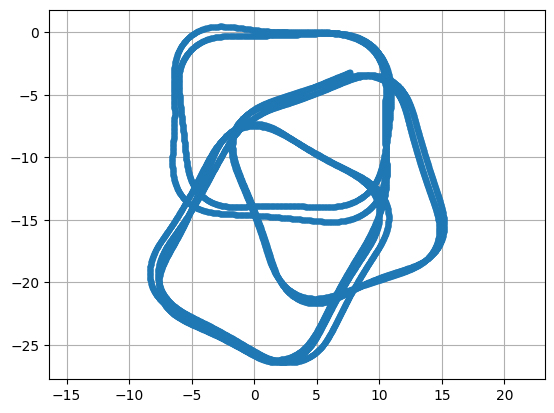

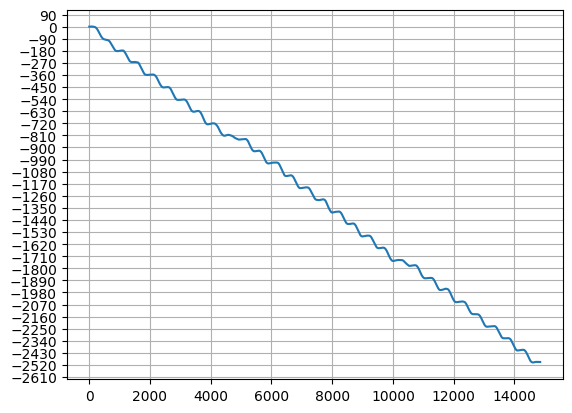

[07] swing_right03.csv                길이:  15191  ≈   5.06 분  opts={'skiprows': 300, 'flag': False, 'zone': 52}


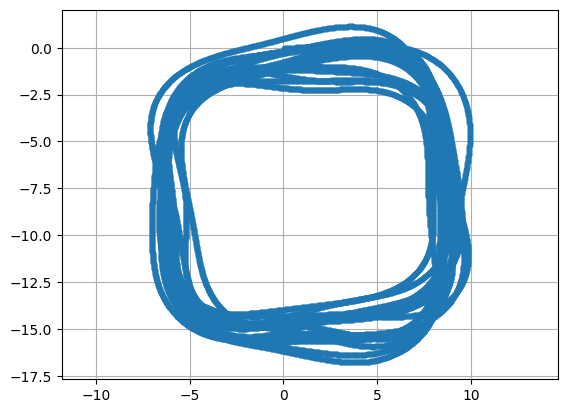

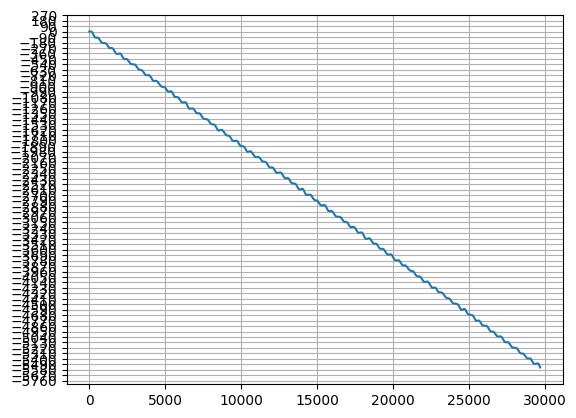

[08] swing_right04.csv                길이:  29961  ≈   9.99 분  opts={'skiprows': 300, 'flag': True, 'zone': 52}


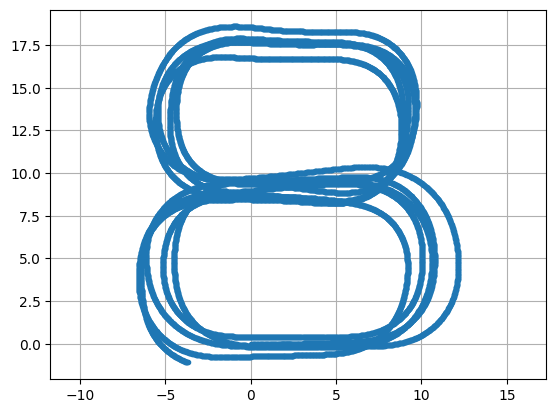

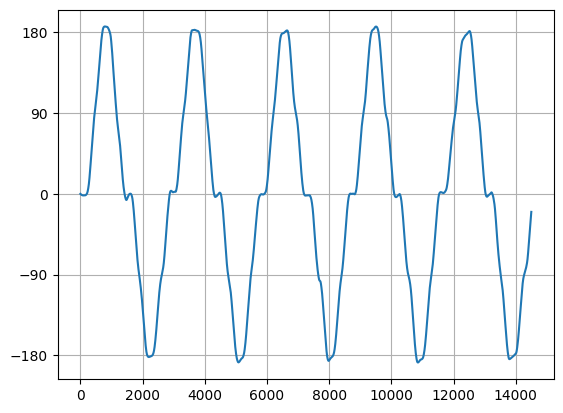

[09] swing_lr01.csv                   길이:  14844  ≈   4.95 분  opts={'skiprows': 100, 'flag': False, 'zone': 52}


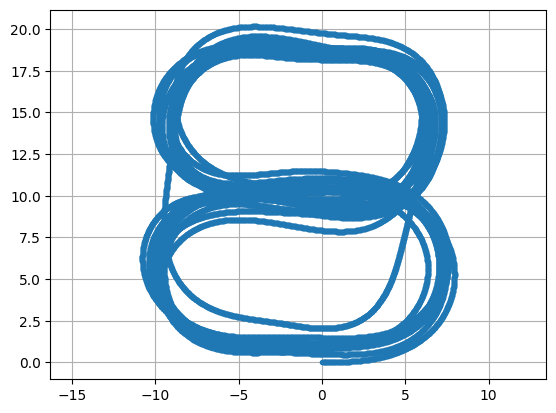

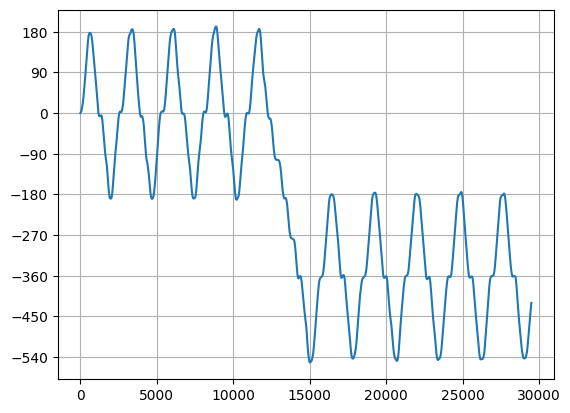

[10] swing_lr02.csv                   길이:  29783  ≈   9.93 분  opts={'skiprows': 300, 'flag': True, 'zone': 52}
--> 그룹 합계: 61.05 분

=== LOOKING 데이터 ===


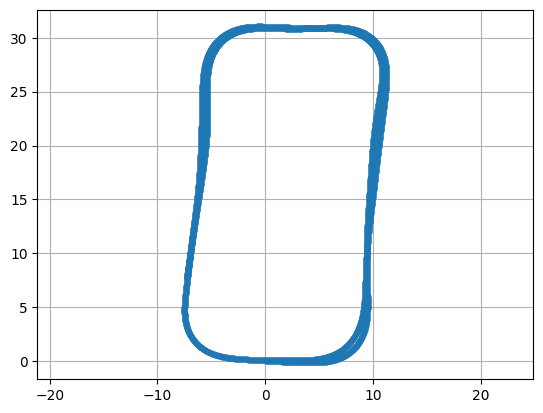

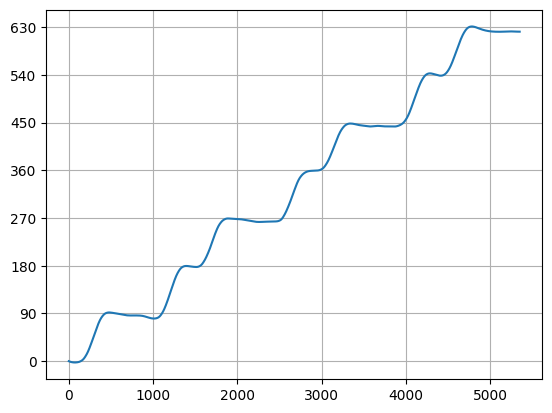

[01] looking_left01.csv               길이:   5695  ≈   1.90 분  opts={'skiprows': 200, 'flag': False, 'zone': 52}


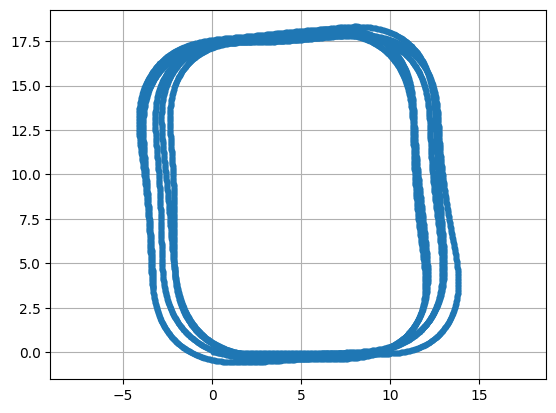

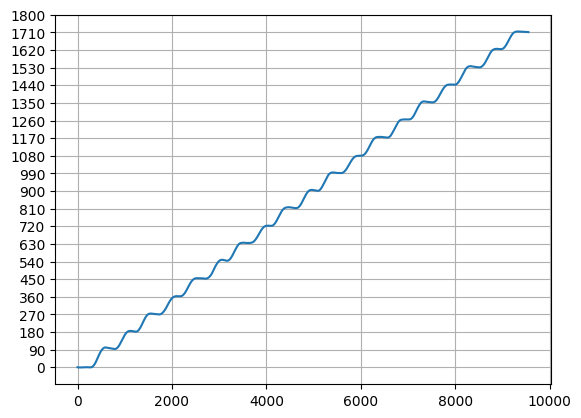

[02] looking_left02.csv               길이:   9857  ≈   3.29 분  opts={'skiprows': 150, 'flag': False, 'zone': 52}


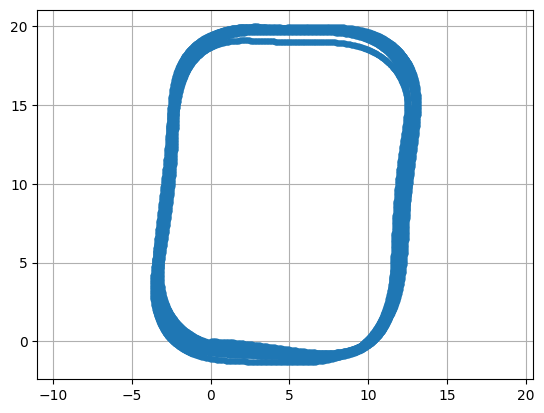

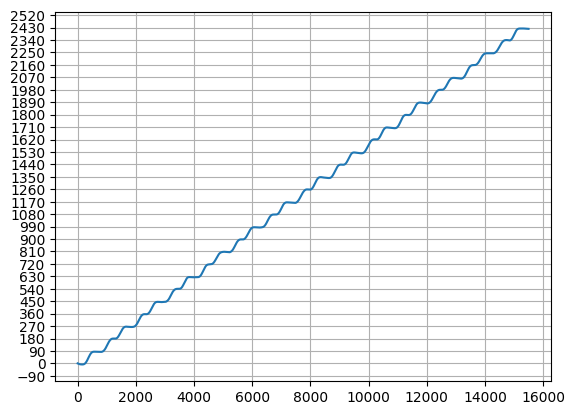

[03] looking_left03.csv               길이:  15829  ≈   5.28 분  opts={'skiprows': 250, 'flag': False, 'zone': 52}


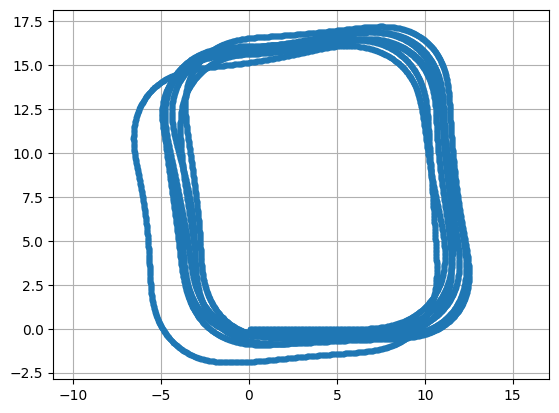

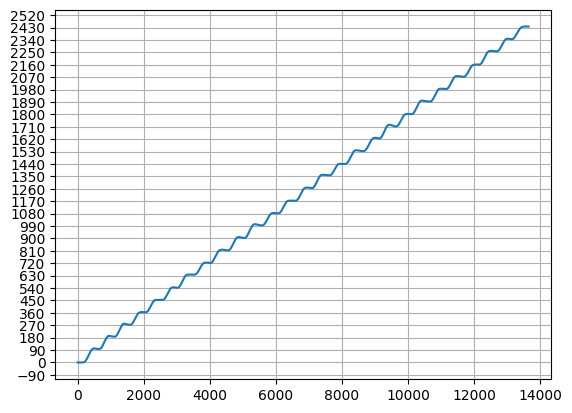

[04] looking_left04.csv               길이:  13960  ≈   4.65 분  opts={'skiprows': 150, 'flag': False, 'zone': 52}


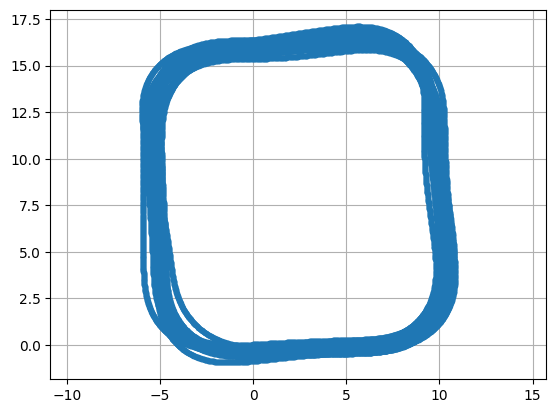

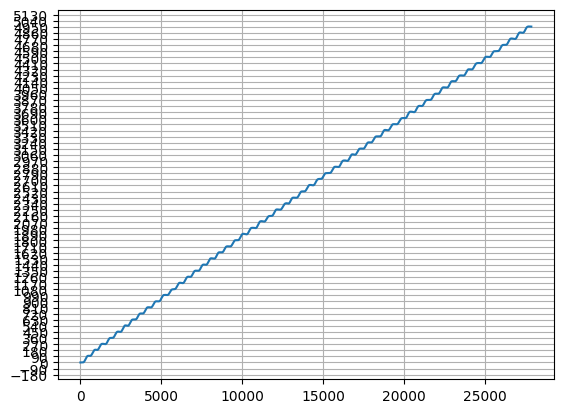

[05] looking_left05.csv               길이:  28149  ≈   9.38 분  opts={'skiprows': 300, 'flag': True, 'zone': 52}


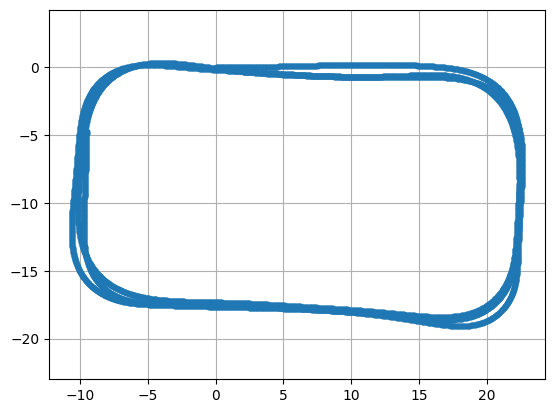

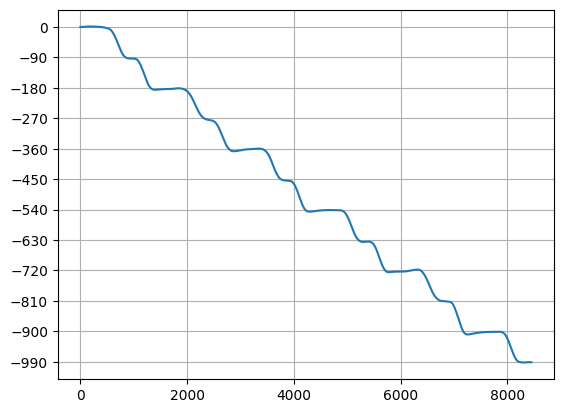

[06] looking_right01.csv              길이:   8756  ≈   2.92 분  opts={'skiprows': 200, 'flag': False, 'zone': 52}


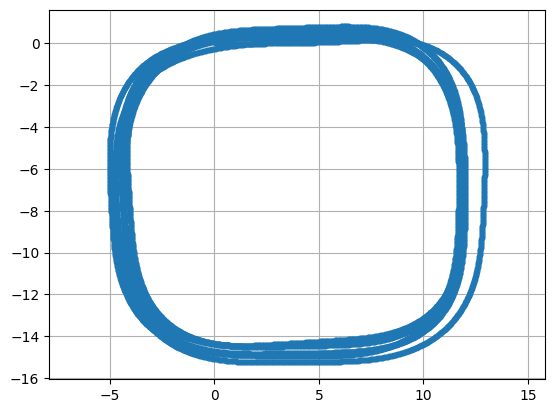

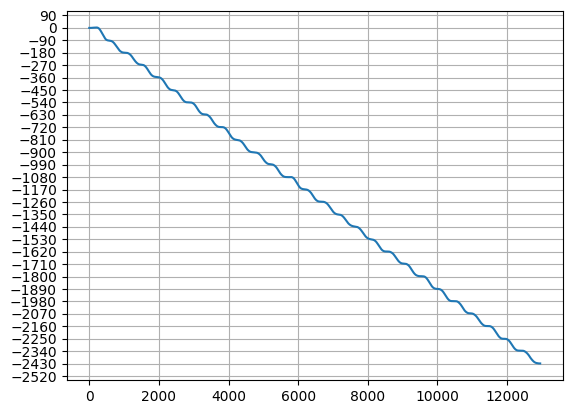

[07] looking_right02.csv              길이:  13262  ≈   4.42 분  opts={'skiprows': 100, 'flag': False, 'zone': 52}


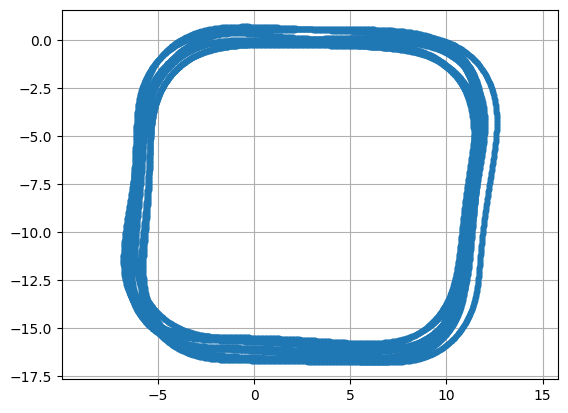

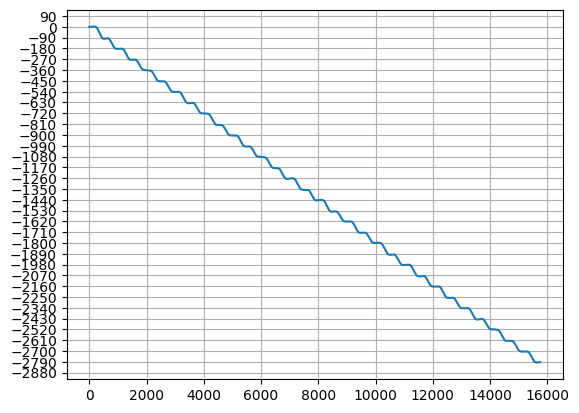

[08] looking_right03.csv              길이:  16091  ≈   5.36 분  opts={'skiprows': 200, 'flag': False, 'zone': 52}


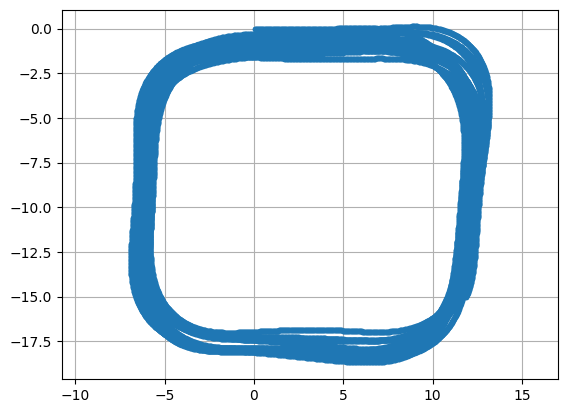

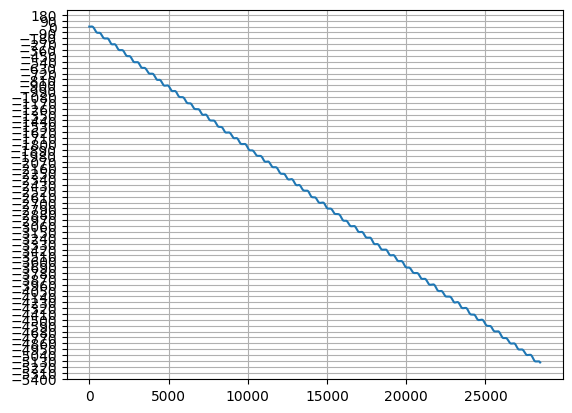

[09] looking_right04.csv              길이:  28704  ≈   9.57 분  opts={'skiprows': 350, 'flag': True, 'zone': 52}


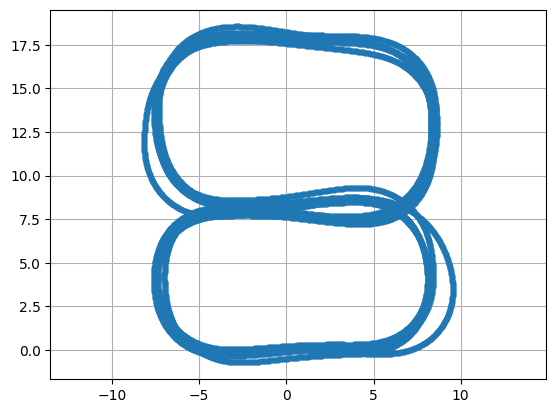

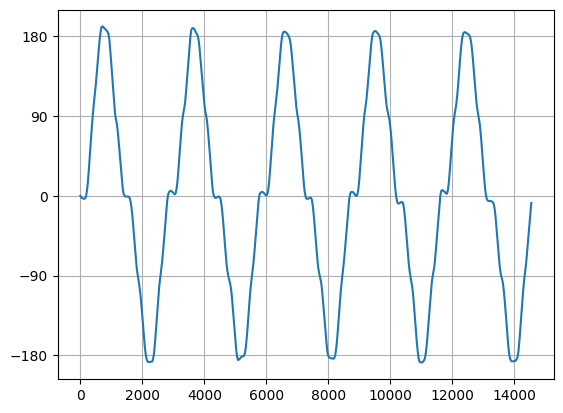

[10] looking_lr01.csv                 길이:  14886  ≈   4.96 분  opts={'skiprows': 100, 'flag': False, 'zone': 52}


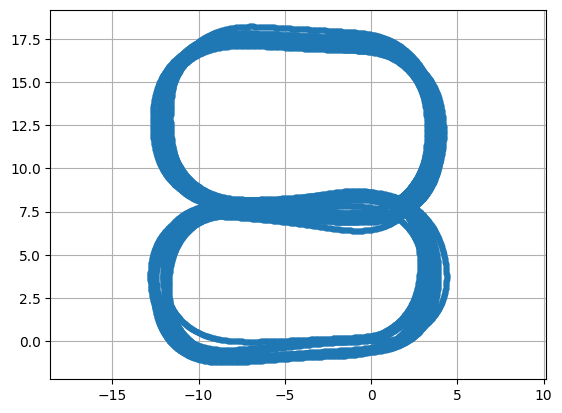

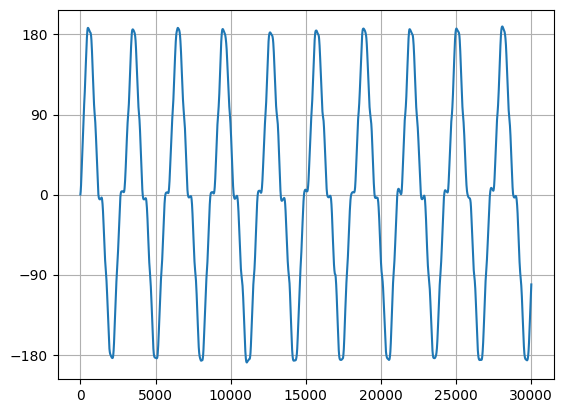

[11] looking_lr02.csv                 길이:  30285  ≈  10.10 분  opts={'skiprows': 500, 'flag': True, 'zone': 52}
--> 그룹 합계: 61.82 분

요약) SWING: 61.05 분 | LOOKING: 61.82 분 | 총합: 122.87 분

=== SWING ===
file                                 min  tag         left_min  right_min
swing_left01.csv                    2.51  left            2.51       0.00
swing_left02.csv                    4.81  left            4.81       0.00
swing_left03.csv                    4.89  left            4.89       0.00
swing_left04.csv                    9.94  left            9.94       0.00
swing_right01.csv                   2.45  right           0.00       2.45
swing_right02.csv                   6.53  right           0.00       6.53
swing_right03.csv                   5.06  right           0.00       5.06
swing_right04.csv                   9.99  right           0.00       9.99
swing_lr01.csv                      4.95  lr(50/50)       2.47       2.47
swing_lr02.csv                      9.93  lr(50/50)       4.9

In [2]:
config = {
    'looking_left01.csv': {'skiprows': 200, 'flag': False, 'zone': 52},
    'looking_left02.csv': {'skiprows': 150, 'flag': False, 'zone': 52},
    'looking_left03.csv': {'skiprows': 250, 'flag': False, 'zone': 52},
    'looking_left04.csv': {'skiprows': 150, 'flag': False, 'zone': 52},
    'looking_left05.csv': {'skiprows': 300, 'flag': True, 'zone': 52},
    
    'looking_right01.csv': {'skiprows': 200, 'flag': False,  'zone': 52},
    'looking_right02.csv': {'skiprows': 100, 'flag': False,  'zone': 52},
    'looking_right03.csv': {'skiprows': 200, 'flag': False,  'zone': 52},
    'looking_right04.csv': {'skiprows': 350, 'flag': True,  'zone': 52},
    
    'looking_lr01.csv':   {'skiprows': 100, 'flag': False,  'zone': 52},
    'looking_lr02.csv':   {'skiprows': 500, 'flag': True,  'zone': 52},
    
    
    'swing_left01.csv' : {'skiprows': 200, 'flag': False, 'zone': 52}, 
    'swing_left02.csv' : {'skiprows': 400, 'flag': False, 'zone': 52}, 
    'swing_left03.csv' : {'skiprows': 200, 'flag': False, 'zone': 52}, 
    'swing_left04.csv' : {'skiprows': 300, 'flag': True, 'zone': 52},  
    
    
    'swing_right01.csv' : {'skiprows': 150, 'flag': False, 'zone': 52},
    'swing_right02.csv' : {'skiprows': 300, 'flag': False, 'zone': 52},
    'swing_right03.csv' : {'skiprows': 300, 'flag': False, 'zone': 52},
    'swing_right04.csv' : {'skiprows': 300, 'flag': True, 'zone': 52},
    
    
    'swing_lr01.csv' : {'skiprows': 100, 'flag': False, 'zone': 52},
    'swing_lr02.csv' : {'skiprows': 300, 'flag': True, 'zone': 52},
    
}

default_config = {'skiprows': 100, 'flag': False, 'zone': 52}

# =========================
# 전역 설정
# =========================
BASE_DIR = os.getcwd()
FS = 50  # Hz

# 학습 데이터 경로들
swing_learnData_path = [
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_left01.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_left02.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_left03.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_left04.csv'),
    
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_right01.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_right02.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_right03.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_right04.csv'),

    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_lr01.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_lr02.csv'),
]

looking_learnData_path = [
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking', 'looking_left01.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking', 'looking_left02.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking', 'looking_left03.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking', 'looking_left04.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking', 'looking_left05.csv'), 

    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking', 'looking_right01.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking', 'looking_right02.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking', 'looking_right03.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking', 'looking_right04.csv'),

    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_lr01.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_lr02.csv'),

]



# =========================
# 그룹 로딩 & 길이 합산
# =========================
def load_group(paths, loader_fn, cfg=None, default_cfg=None, fs=FS):
    """
    한 그룹(paths) 로드/전처리, 파일별 옵션 자동 적용.
      - loader_fn(path, **opts) -> (df, X, Y)
      - cfg: 파일명별 옵션 dict
      - default_cfg: 기본 옵션 dict
    """
    cfg = cfg or {}
    default_cfg = default_cfg or {}
    df_list, X_list, Y_list = [], [], []
    total_min = 0.0

    for idx, p in enumerate(paths, start=1):
        fname = Path(p).name
        opts = {**default_cfg, **cfg.get(fname, {})}  # default + per-file override

        try:
            df_temp, X_temp, Y_temp = loader_fn(p, **opts)
        except Exception as e:
            print(f'[에러] {fname}: {e}')
            continue

        df_list.append(df_temp)
        X_list.append(X_temp)
        Y_list.append(Y_temp)

        minutes = len(df_temp) / fs / 60.0
        print(f'[{idx:02d}] {fname:<32} 길이:{len(df_temp):7d}  ≈ {minutes:6.2f} 분  opts={opts}')
        total_min += minutes

    print(f'--> 그룹 합계: {total_min:.2f} 분\n')
    return df_list, X_list, Y_list, total_min

# =========================
# 좌/우/혼합 분량 요약
# =========================
def summarize_turn_minutes(df_list, paths, fs=FS):
    """
    df_list: 각 파일의 DataFrame 리스트
    paths  : 각 파일의 경로 리스트 (df_list와 동일 순서)
    fs     : 샘플링 주파수(Hz)
    return : (per_file_rows, totals)
    """
    rows = []
    tot_left = 0.0
    tot_right = 0.0
    for df, p in zip(df_list, paths):
        fname = Path(p).name
        name = fname.lower()
        minutes = len(df) / fs / 60.0

        if ("lr" in name) or ("left" in name and "right" in name):
            # 혼합 데이터 → 좌/우 반반
            left_min = minutes / 2.0
            right_min = minutes / 2.0
            tag = "lr(50/50)"
        elif "left" in name:
            left_min = minutes
            right_min = 0.0
            tag = "left"
        elif "right" in name:
            left_min = 0.0
            right_min = minutes
            tag = "right"
        else:
            left_min = 0.0
            right_min = 0.0
            tag = "unknown"

        tot_left += left_min
        tot_right += right_min
        rows.append({
            'file': fname,
            'minutes': round(minutes, 2),
            'tag': tag,
            'left_min': round(left_min, 2),
            'right_min': round(right_min, 2),
        })

    totals = {
        'left': round(tot_left, 2),
        'right': round(tot_right, 2),
        'total': round(tot_left + tot_right, 2),
    }
    return rows, totals

def pretty_print_summary(title, rows, totals):
    print(f"\n=== {title} ===")
    print(f"{'file':32} {'min':>7}  {'tag':10} {'left_min':>9} {'right_min':>10}")
    for r in rows:
        print(f"{r['file']:<32} {r['minutes']:7.2f}  {r['tag']:<10} {r['left_min']:9.2f} {r['right_min']:10.2f}")
    print(f"-- 합계: left={totals['left']:.2f} min | right={totals['right']:.2f} min | total={totals['total']:.2f} min")

# (선택) 판다스 표/CSV 저장
def to_dataframe(rows):
    return pd.DataFrame(rows, columns=['file','minutes','tag','left_min','right_min'])

def save_summary_csv(prefix, rows, totals, out_dir="outputs"):
    os.makedirs(out_dir, exist_ok=True)
    df = to_dataframe(rows)
    df.to_csv(os.path.join(out_dir, f"{prefix}_per_file.csv"), index=False, encoding="utf-8-sig")
    pd.DataFrame([totals]).to_csv(os.path.join(out_dir, f"{prefix}_totals.csv"), index=False, encoding="utf-8-sig")

# =========================
# 실행부
# =========================
if __name__ == "__main__":
    loader1 = lambda path, **opts: DataProcessor.load_and_preprocess_csv(path, **opts)

    print('=== SWING 데이터 ===')
    swing_df_list, swing_X_list, swing_Y_list, swing_min = load_group(
        swing_learnData_path, loader_fn=loader1, cfg=config, default_cfg=default_config
    )

    print('=== LOOKING 데이터 ===')
    looking_df_list, looking_X_list, looking_Y_list, looking_min = load_group(
        looking_learnData_path, loader_fn=loader1, cfg=config, default_cfg=default_config
    )

    print(f'요약) SWING: {swing_min:.2f} 분 | LOOKING: {looking_min:.2f} 분 | 총합: {swing_min + looking_min:.2f} 분')

    # 좌/우/혼합 분량 요약
    swing_rows, swing_tot = summarize_turn_minutes(swing_df_list, swing_learnData_path, fs=FS)
    pretty_print_summary("SWING", swing_rows, swing_tot)

    looking_rows, looking_tot = summarize_turn_minutes(looking_df_list, looking_learnData_path, fs=FS)
    pretty_print_summary("LOOKING", looking_rows, looking_tot)

    # 전체 합산
    all_rows = swing_rows + looking_rows
    all_tot = {
        'left':  round(swing_tot['left']  + looking_tot['left'],  2),
        'right': round(swing_tot['right'] + looking_tot['right'], 2),
        'total': round(swing_tot['total'] + looking_tot['total'], 2),
    }
    pretty_print_summary("전체(SWING + LOOKING)", all_rows, all_tot)